# Simulate, Summarize, Reduce, Cluster, and Analyze (SSRCA) methodology

Similar to [Rohr & Nardini 2026](https://doi.org/10.1007/s11538-026-01604-8), we apply SSRCA methodology in this jupyter notebook.

***Simulate***: Simulations were obtain from Sobol sequence sampling and stored in [Simulations.db](./Simulations.db).

***Summarize***: The simulations can be summarized using custom lambda function defined here.

In [1]:
from uq_physicell.model_analysis import calculate_qoi_from_db_file, get_summary_statistics_qois
from uq_physicell.utils.sumstats import qoi_func_radial_density_summary

import os
import numpy as np
import pandas as pd
import scipy
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

def calculate_spatial_qois(points):
    """
    points: Nx2 array of (x, y) coordinates for all living cells
    """
    # 1. Voronoi Area CV (The Pressure Sensor)
    vor = scipy.spatial.Voronoi(points)
    areas = []
    for i, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if -1 in region or len(region) == 0: 
            # Skip infinite/incomplete regions at the tumor edge
            continue
        # Calculate area of polygon using Shoelace Formula
        polygon = vor.vertices[region]
        area = 0.5 * np.abs(np.dot(polygon[:,0], np.roll(polygon[:,1], 1)) - 
                            np.dot(polygon[:,1], np.roll(polygon[:,0], 1)))
        areas.append(area)
    vor_cv = np.std(areas) / np.mean(areas) if areas else 0
    # 2. Convex Hull Ratio (The Solidity Sensor)
    hull = scipy.spatial.ConvexHull(points)
    # Note: hull.volume is Area in 2D
    # Actual area can be approximated by sum of Voronoi areas or 
    # the area of an Alpha Shape if the tumor is porous.
    total_vor_area = np.sum(areas) 
    solidity = total_vor_area / hull.volume 
    return {
        "voronoi_cv": vor_cv,
        "solidity": solidity,
        "convex_hull_area": hull.volume
    }

db_file = 'Simulations.db'
qoi_funcs = {
    # Kinetic and global QoIs
    'live_cell_count': lambda df: len( df[ df['dead'] == False ]),
    'dead_cell_count': lambda df: len( df[ df['dead'] == True ]),
    'sum_live_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == False]), mcds_ts)),
    'sum_dead_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == True]), mcds_ts)),
    'tumor_radius': lambda df:  ( (df['position_x'].max() - df['position_x'].min())**2 + (df['position_y'].max() - df['position_y'].min())**2 )**0.5, 
    # Spatial Architecture Metrics ("pressure sensors")
    'spatial_architecture': lambda df: calculate_spatial_qois(df[['position_x', 'position_y']].values),
    # Radial Density Metrics ("solidity sensors")
    'radial_density': lambda df: qoi_func_radial_density_summary(df)

}

df_all_file_dataset = 'QoIs_all.parquet' 
df_qois_file_mean = 'QoIs_mean.parquet'
df_qois_file_std = 'QoIs_std.parquet'
df_qois_file_mcse = 'QoIs_mcse.parquet'
if os.path.exists(df_all_file_dataset):
    df_all_dataset = pd.read_parquet(df_all_file_dataset)
    df_qois_mean = pd.read_parquet(df_qois_file_mean)
    df_qois_std = pd.read_parquet(df_qois_file_std)
    df_qois_mcse = pd.read_parquet(df_qois_file_mcse)
else:
    chunk_size = 100
    df_all_dataset = calculate_qoi_from_db_file(db_file, qoi_funcs, qoi_def={'spatial_architecture': calculate_spatial_qois, 'radial_density': qoi_func_radial_density_summary}, chunk_size=chunk_size)
    df_qois_mean, df_qois_std, df_qois_mcse = get_summary_statistics_qois(df_all_dataset)
    # Save dataframes
    df_qois_mean.to_parquet(df_qois_file_mean)
    df_qois_std.to_parquet(df_qois_file_std)
    df_qois_mcse.to_parquet(df_qois_file_mcse)
    df_all_dataset.to_parquet(df_all_file_dataset)

display(df_qois_mean)

dead_cell_count  live_cell_count  \
SampleID time                                       
0        0.0                 0.0            511.0   
         240.0               6.8            582.6   
         480.0              13.2            632.4   
         720.0              15.6            673.6   
         960.0              18.0            712.0   
...                          ...              ...   
47       6240.0             44.0           1869.4   
         6480.0             48.4           1933.4   
         6720.0             45.2           2004.6   
         6960.0             47.2           2078.8   
         7200.0             50.6           2147.0   

                 radial_density_center_of_mass  radial_density_iqr  \
SampleID time                                                        
0        0.0                        133.138630           72.533943   
         240.0                      133.909782           72.888028   
         480.0                      136.801658           75.748858   
         720.0                      141.154089           77.480334   
         960.0                      145.459284           81.125033   
...                                        ...                 ...   
47       6240.0                     234.486268          129.336595   
         6480.0                     238.730513          131.713234   
         6720.0                     242.770959          134.067686   
         6960.0                     247.280883          136.890036   
         7200.0                     251.151329          139.037779   

                 radial_density_kurtosis  radial_density_median  \
SampleID time                                                     
0        0.0                   -0.601620             141.365834   
         240.0                 -0.591397             142.063905   
         480.0                 -0.618651             144.877013   
         720.0                 -0.616477             149.445954   
         960.0                 -0.627557             153.726347   
...                                  ...                    ...   
47       6240.0                -0.617947             247.775117   
         6480.0                -0.617342             252.154255   
         6720.0                -0.614482             256.204802   
         6960.0                -0.617573             261.327744   
         7200.0                -0.620377             265.185579   

                 radial_density_skewness  radial_density_spread  \
SampleID time                                                     
0        0.0                   -0.564439              47.075631   
         240.0                 -0.557347              47.354427   
         480.0                 -0.533443              49.039586   
         720.0                 -0.527943              50.503039   
         960.0                 -0.517207              52.124240   
...                                  ...                    ...   
47       6240.0                -0.516025              83.921383   
         6480.0                -0.515405              85.481459   
         6720.0                -0.518900              86.924878   
         6960.0                -0.518507              88.380546   
         7200.0                -0.516642              89.890316   

                 spatial_architecture_convex_hull_area  \
SampleID time                                            
0        0.0                             118415.798267   
         240.0                           122572.662758   
         480.0                           131446.621342   
         720.0                           140538.913243   
         960.0                           149580.781696   
...                                                ...   
47       6240.0                          394733.905826   
         6480.0                          409735.904843   
         6720.0                          423472.896272   
         6960.0                   

## Replicate Check (MCSE)

Decide if we have a stable "signature" for the QoIs.

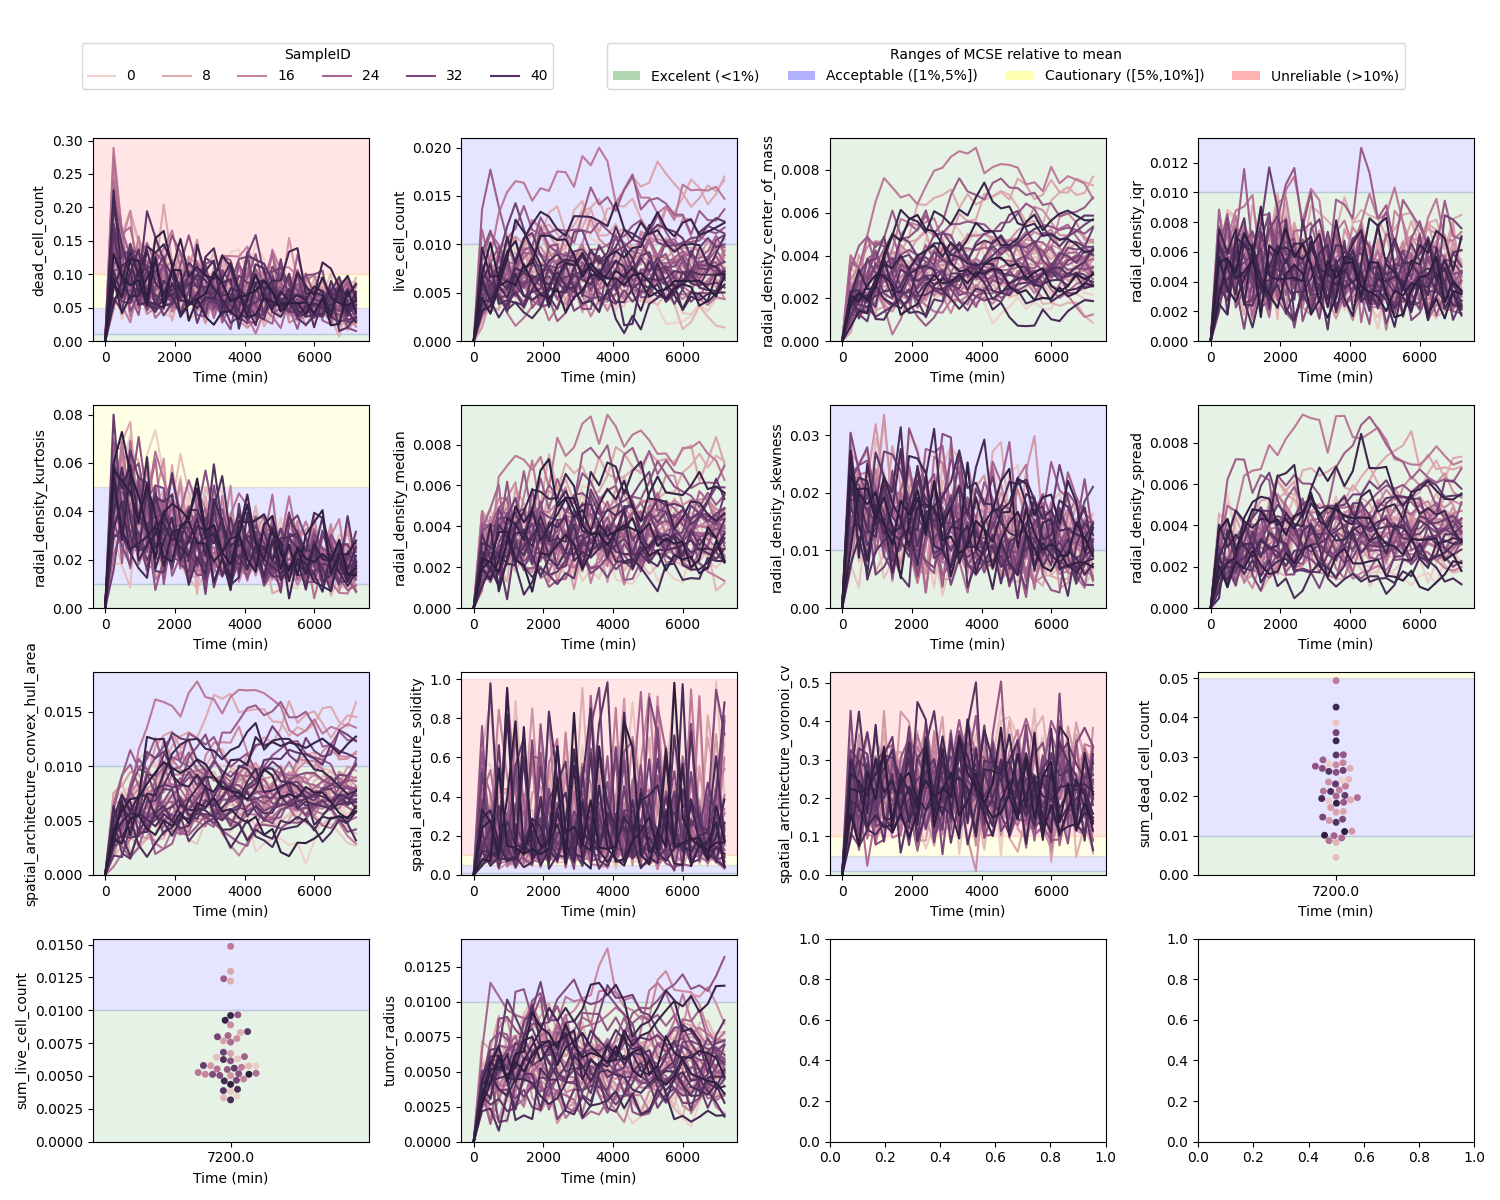

In [2]:
import matplotlib.pyplot as plt
from matplotlib.legend import Legend
from uq_physicell.model_analysis import plot_qoi_over_time

# Prevent notebook inline backend from tight-cropping artists outside the axes
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
qois_names = [col for col in df_qois_mean.columns]

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()
for ax_id, qoi_name in enumerate(qois_names):
    ax = axes[ax_id]
    plot_qoi_over_time(df_qois_mcse, qoi_name, ax, plot_mcse_range=True)

# Extract legend entries, separating SampleID from MCSE to avoid duplicates
sample_pairs = {}
mcse_pairs = {}
for legend_obj in axes[0].findobj(Legend):
    legend_texts = [t.get_text() for t in legend_obj.get_texts()]
    legend_handles = legend_obj.legend_handles
    for handle, label in zip(legend_handles, legend_texts):
        # MCSE legends use percentage signs in visualization.py
        if '%' in label:  
            if label not in mcse_pairs:
                mcse_pairs[label] = handle
        # Sample legends are numeric
        elif str(label).strip().isdigit():
            if label not in sample_pairs:
                sample_pairs[label] = handle

# Hide all legends inside subplots to clean up clutter
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.set_visible(False)
        legend.set_in_layout(False)
    for legend_artist in ax.findobj(Legend):
        legend_artist.set_visible(False)
        legend_artist.set_in_layout(False)

# Add Figure-level legend for Sample IDs at the top
if sample_pairs:
    fig.legend(
        list(sample_pairs.values()),
        list(sample_pairs.keys()),
        title='SampleID',
        loc='upper left',
        ncol=min(len(sample_pairs), 10),
        bbox_to_anchor=(0.05, 0.97)
    )

# Add Figure-level legend for MCSE Ranges at the bottom
if mcse_pairs:
    fig.legend(
        list(mcse_pairs.values()),
        list(mcse_pairs.keys()),
        title='Ranges of MCSE relative to mean',
        loc='upper left',
        ncol=4,
        bbox_to_anchor=(0.40, 0.97)
    )

# Leave space at the top and bottom of the plot explicitly
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.savefig('QoI_Results.svg', format='svg', bbox_inches='tight')
plt.show()

In [3]:
from uq_physicell.model_analysis import load_samples
from uq_physicell.model_analysis.utils import recursive_feature_elimination

# Load parameters indexed by SampleID
df_params = pd.DataFrame.from_dict(load_samples(db_file), orient='index').sort_index()
dic_RFE_results = recursive_feature_elimination(df_qois_mean, df_qois_mcse, df_params, verbose=True)

✓ Trajectory QoIs filled (NaN→last value per sample): ['sum_dead_cell_count', 'sum_live_cell_count']

[STAGE 1] Pathological Noise Removal (MCSE > 10.0%)
  Removed 3/14 pathological features: ['dead_cell_count', 'spatial_architecture_solidity', 'spatial_architecture_voronoi_cv']

[STAGE 2] Redundancy Removal (Correlation > 95.0%)
  Removed 6/11 redundant features: ['live_cell_count', 'radial_density_iqr', 'radial_density_median', 'radial_density_spread', 'spatial_architecture_convex_hull_area', 'tumor_radius']

[STAGE 3] Autoencoder on Cleaned Features (5 QoIs)
Using PyTorch autoencoder
AE epoch 1/200 loss=0.981367
AE epoch 21/200 loss=0.271915
AE epoch 41/200 loss=0.233725
AE epoch 61/200 loss=0.226323
AE epoch 81/200 loss=0.222258
AE epoch 101/200 loss=0.219392
AE epoch 121/200 loss=0.216718
AE epoch 141/200 loss=0.214085
AE epoch 161/200 loss=0.211823
AE epoch 181/200 loss=0.209404
AE epoch 200/200 loss=0.20716
  Full AE → Params R² (mean): -0.0158

[STAGE 4] RFECV-based Feature Sel

In [4]:
display(dic_RFE_results['reduced_regression_r2'])
display(dic_RFE_results['final_qois']       )

,R2_CV
apoptosis_rate,0.823871
cell_cycle_entry,0.635336


['sum_dead_cell_count', 'sum_live_cell_count']

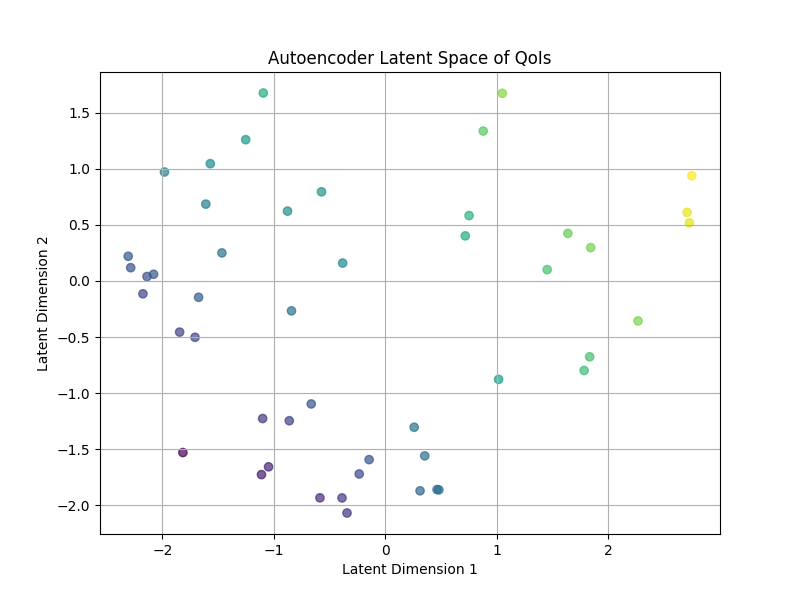

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
df_plot = df_qois_mean.reset_index()
dict_autoencoder_results = dic_RFE_results['reduced_autoencoder_results']
feature_colored = 'sum_dead_cell_count'# 'time', 'live_cell_count', 'sum_dead_cell_count'
plt.scatter(dict_autoencoder_results['encoder_output'][:, 0], dict_autoencoder_results['encoder_output'][:, 1], c=df_plot[feature_colored].to_numpy(), alpha=0.7)
plt.title('Autoencoder Latent Space of QoIs')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True)

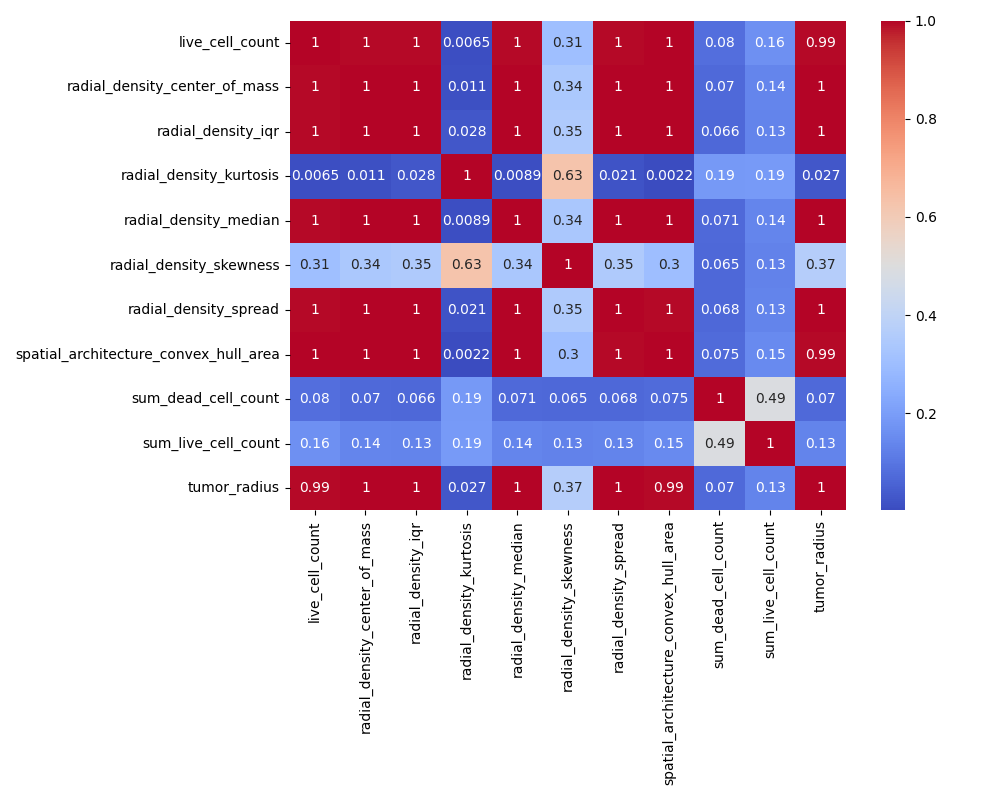

In [6]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(dic_RFE_results['correlation_matrix'], annot=True, cmap='coolwarm')
plt.tight_layout()